🌱 AGRIVISION AI - PEST CLASSIFICATION

TensorFlow Version: 2.20.0
✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

⚙️ Training Configuration
Image Size : 160 x 160
Batch Size : 64
Epochs     : 5
Classes    : 102

📥 DOWNLOADING IP102 DATASET...
Using Colab cache for faster access to the 'ip02-dataset' dataset.

✅ Dataset downloaded!
📁 Location: /kaggle/input/ip02-dataset

🔍 Searching for pest images...
✅ Total images found: 75222

⚡ Creating image index...
✅ Indexed: 75222 images

🔍 Searching for train/val/test files...

TXT files found:
    /kaggle/input/ip02-dataset/val.txt
    /kaggle/input/ip02-dataset/test.txt
    /kaggle/input/ip02-dataset/train.txt
    /kaggle/input/ip02-dataset/classes.txt

📄 Dataset files:
Train      : /kaggle/input/ip02-dataset/train.txt
Validation : /kaggle/input/ip02-dataset/val.txt
Test       : /kaggle/input/ip02-dataset/test.txt
Classes    : /kaggle/input/ip02-dataset/classes.txt

📊 Reading dataset splits...

Dataset Stat

Model: "AgriVision_Pest_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,388,646 (9.11 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 2,257,984 (8.61 MB)



🚀 STARTING MODEL TRAINING
Epoch 1/5
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.3138 - loss: 2.8695
Epoch 1: val_accuracy improved from None to 0.37413, saving model to /content/best_agrivision_pest.keras

Epoch 1: finished saving model to /content/best_agrivision_pest.keras
705/705 ━━━━━━━━━━━━━━━━━━━━ 184s 247ms/step - accuracy: 0.4062 - loss: 2.5172 - val_accuracy: 0.3741 - val_loss: 2.7074 - learning_rate: 0.0010
Epoch 2/5
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4642 - loss: 2.0814
Epoch 2: val_accuracy improved from 0.37413 to 0.41676, saving model to /content/best_agrivision_pest.keras

Epoch 2: finished saving model to /content/best_agrivision_pest.keras
705/705 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.5091 - loss: 1.9279 - val_accuracy: 0.4168 - val_loss: 2.4523 - learning_rate: 0.0010
Epoch 3/5
704/705 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5039 - loss: 1.9000
Epoch 3: val_accuracy did not improve from 0.41676
705/705 ━━━━━━━━

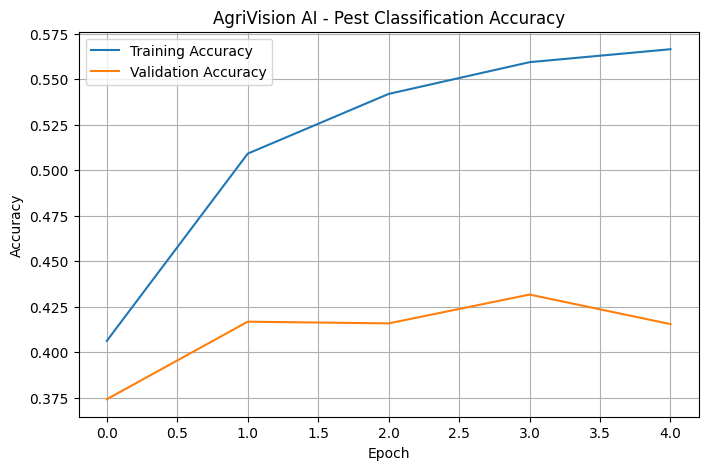

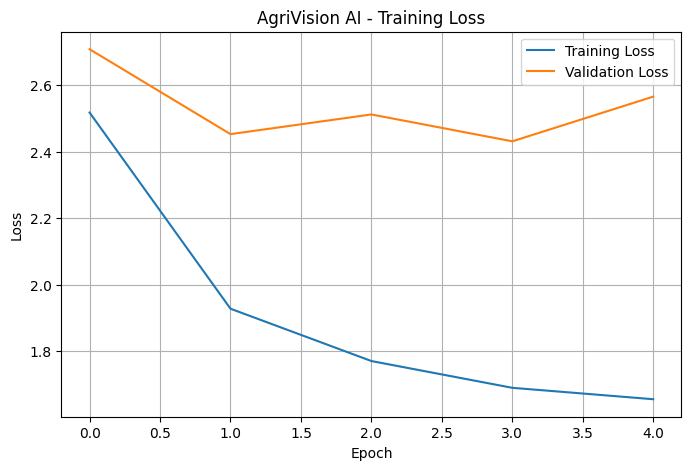


📦 MODEL FILE SIZES
Keras  : 10.68 MB
TFLite : 2.52 MB


🎉 AGRIVISION AI PEST MODEL COMPLETE!

Final Test Accuracy : 43.29%

Files Created:

1. agrivision_pest_model.keras
2. agrivision_pest_model.tflite
3. pest_classes.txt

Pipeline:

IP102
  ↓
75,000+ Pest Images
  ↓
Resize 160×160
  ↓
Data Augmentation
  ↓
MobileNetV2
  ↓
Transfer Learning
  ↓
102 Pest Classes
  ↓
Keras Model
  ↓
TFLite Model
  ↓
Flutter AgriVision AI

Files are available inside the /content folder.

To download manually:
Colab → Files → content → Right click file → Download


In [1]:
# ============================================================
# 🐛 AGRIVISION AI - IP102 PEST CLASSIFICATION
# MobileNetV2 + Transfer Learning
# Complete Google Colab Code - Run in ONE CELL
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL REQUIRED PACKAGE
# ------------------------------------------------------------

!pip install -q kagglehub


# ------------------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import numpy as np
import tensorflow as tf
import kagglehub
import matplotlib.pyplot as plt

from tensorflow.keras import layers


# ------------------------------------------------------------
# 3. CHECK GPU
# ------------------------------------------------------------

print("=" * 60)
print("🌱 AGRIVISION AI - PEST CLASSIFICATION")
print("=" * 60)

print("\nTensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("✅ GPU detected:", gpus)
else:
    print("⚠️ GPU NOT detected.")
    print("Go to Runtime → Change runtime type → GPU")


# ------------------------------------------------------------
# 4. SETTINGS
# ------------------------------------------------------------

IMG_SIZE = 160

# Change to 32 if you get GPU memory error
BATCH_SIZE = 64

# Start with 5 for fast training
EPOCHS = 5

NUM_CLASSES = 102

AUTOTUNE = tf.data.AUTOTUNE


print("\n⚙️ Training Configuration")
print("Image Size :", IMG_SIZE, "x", IMG_SIZE)
print("Batch Size :", BATCH_SIZE)
print("Epochs     :", EPOCHS)
print("Classes    :", NUM_CLASSES)


# ------------------------------------------------------------
# 5. DOWNLOAD IP102 DATASET
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("📥 DOWNLOADING IP102 DATASET...")
print("=" * 60)

dataset_path = kagglehub.dataset_download(
    "rtlmhjbn/ip02-dataset"
)

print("\n✅ Dataset downloaded!")
print("📁 Location:", dataset_path)


# ------------------------------------------------------------
# 6. FIND ALL IMAGES
# ------------------------------------------------------------

print("\n🔍 Searching for pest images...")

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

all_images = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(image_extensions):

            full_path = os.path.join(
                root,
                file
            )

            all_images.append(full_path)


print("✅ Total images found:", len(all_images))

if len(all_images) == 0:
    raise RuntimeError(
        "No images found inside downloaded dataset."
    )


# ------------------------------------------------------------
# 7. CREATE FAST IMAGE LOOKUP
# ------------------------------------------------------------

print("\n⚡ Creating image index...")

image_lookup = {}

for path in all_images:

    filename = os.path.basename(path)

    image_lookup[filename] = path


print("✅ Indexed:", len(image_lookup), "images")


# ------------------------------------------------------------
# 8. FIND TXT SPLIT FILES
# ------------------------------------------------------------

print("\n🔍 Searching for train/val/test files...")

txt_files = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(".txt"):

            txt_files.append(
                os.path.join(root, file)
            )


print("\nTXT files found:")

for file in txt_files:
    print("   ", file)


# ------------------------------------------------------------
# 9. IDENTIFY TRAIN / VAL / TEST FILES
# ------------------------------------------------------------

train_file = None
val_file = None
test_file = None
classes_file = None


for file in txt_files:

    name = os.path.basename(file).lower()

    if name == "train.txt":
        train_file = file

    elif name in [
        "val.txt",
        "validation.txt"
    ]:
        val_file = file

    elif name == "test.txt":
        test_file = file

    elif name in [
        "classes.txt",
        "class.txt",
        "labels.txt"
    ]:
        classes_file = file


print("\n📄 Dataset files:")

print("Train      :", train_file)
print("Validation :", val_file)
print("Test       :", test_file)
print("Classes    :", classes_file)


if train_file is None:
    raise RuntimeError(
        "❌ train.txt could not be found."
    )

if val_file is None:
    raise RuntimeError(
        "❌ val.txt could not be found."
    )

if test_file is None:
    raise RuntimeError(
        "❌ test.txt could not be found."
    )


# ------------------------------------------------------------
# 10. READ DATASET SPLIT
# ------------------------------------------------------------

def read_split(txt_path):

    paths = []
    labels = []

    with open(
        txt_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) < 2:
                continue

            image_name = parts[0]

            try:
                label = int(parts[1])
            except:
                continue

            # Try exact filename
            path = image_lookup.get(
                os.path.basename(image_name)
            )

            if path is not None:

                paths.append(path)
                labels.append(label)

    return paths, labels


# ------------------------------------------------------------
# 11. LOAD TRAIN / VAL / TEST
# ------------------------------------------------------------

print("\n📊 Reading dataset splits...")

train_images, train_labels = read_split(
    train_file
)

val_images, val_labels = read_split(
    val_file
)

test_images, test_labels = read_split(
    test_file
)


print("\nDataset Statistics")
print("-" * 40)

print(
    "Training images   :",
    len(train_images)
)

print(
    "Validation images :",
    len(val_images)
)

print(
    "Testing images    :",
    len(test_images)
)


if len(train_images) == 0:
    raise RuntimeError(
        "❌ No training images matched train.txt."
    )


# ------------------------------------------------------------
# 12. CHECK LABELS
# ------------------------------------------------------------

all_labels_check = (
    train_labels +
    val_labels +
    test_labels
)

print("\n🏷️ Label information")

print(
    "Minimum label:",
    min(all_labels_check)
)

print(
    "Maximum label:",
    max(all_labels_check)
)

print(
    "Unique classes:",
    len(set(all_labels_check))
)


# ------------------------------------------------------------
# 13. CONVERT LABELS TO 0-101 IF NECESSARY
# ------------------------------------------------------------

minimum_label = min(all_labels_check)

if minimum_label == 1:

    print(
        "\n🔄 Converting labels "
        "from 1-102 → 0-101"
    )

    train_labels = [
        label - 1
        for label in train_labels
    ]

    val_labels = [
        label - 1
        for label in val_labels
    ]

    test_labels = [
        label - 1
        for label in test_labels
    ]

else:

    print(
        "\n✅ Labels already start from 0"
    )


# ------------------------------------------------------------
# 14. IMAGE LOADING FUNCTION
# ------------------------------------------------------------

def load_image(path, label):

    # Read image
    image = tf.io.read_file(path)

    # Automatically decode JPG/PNG/etc.
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Give TensorFlow known channel shape
    image.set_shape(
        [None, None, 3]
    )

    # Resize
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # MobileNetV2 preprocessing
    image = (
        tf.keras.applications
        .mobilenet_v2
        .preprocess_input(image)
    )

    return image, label


# ------------------------------------------------------------
# 15. CREATE FAST DATASET
# ------------------------------------------------------------

def create_dataset(
    paths,
    labels,
    training=False
):

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (paths, labels)
        )
    )

    if training:

        dataset = dataset.shuffle(
            min(
                len(paths),
                10000
            )
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


print("\n⚙️ Creating TensorFlow datasets...")


train_ds = create_dataset(
    train_images,
    train_labels,
    training=True
)

val_ds = create_dataset(
    val_images,
    val_labels
)

test_ds = create_dataset(
    test_images,
    test_labels
)


print("✅ TensorFlow datasets ready!")


# ------------------------------------------------------------
# 16. DATA AUGMENTATION
# ------------------------------------------------------------

data_augmentation = tf.keras.Sequential(
    [

        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.08
        ),

        layers.RandomZoom(
            0.08
        )

    ],
    name="data_augmentation"
)


# ------------------------------------------------------------
# 17. LOAD MOBILENETV2
# ------------------------------------------------------------

print("\n🧠 Loading MobileNetV2...")

base_model = (
    tf.keras.applications
    .MobileNetV2(

        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),

        include_top=False,

        # Transfer learning
        weights="imagenet"
    )
)


# ------------------------------------------------------------
# 18. FREEZE MOBILENET
# ------------------------------------------------------------

# IMPORTANT:
# Freezing MobileNetV2 makes training MUCH faster.

base_model.trainable = False


print("✅ MobileNetV2 loaded!")
print("🔒 Backbone frozen for fast training")


# ------------------------------------------------------------
# 19. CREATE AGRIVISION MODEL
# ------------------------------------------------------------

print("\n🏗️ Building AgriVision Pest Model...")


inputs = tf.keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)


# Data augmentation
x = data_augmentation(
    inputs
)


# MobileNet features
x = base_model(
    x,
    training=False
)


# Reduce feature maps
x = layers.GlobalAveragePooling2D()(
    x
)


# Prevent overfitting
x = layers.Dropout(
    0.25
)(x)


# 102 pest classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


model = tf.keras.Model(
    inputs,
    outputs,
    name="AgriVision_Pest_MobileNetV2"
)


# ------------------------------------------------------------
# 20. COMPILE MODEL
# ------------------------------------------------------------

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=(
        "sparse_categorical_crossentropy"
    ),

    metrics=[
        "accuracy"
    ]
)


# ------------------------------------------------------------
# 21. MODEL SUMMARY
# ------------------------------------------------------------

print("\n")
model.summary()


# ------------------------------------------------------------
# 22. CALLBACKS
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/content/best_agrivision_pest.keras"
)


callbacks = [

    # Save best model
    tf.keras.callbacks.ModelCheckpoint(

        BEST_MODEL_PATH,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1
    ),

    # Stop unnecessary training
    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=3,

        restore_best_weights=True,

        verbose=1
    ),

    # Automatically reduce LR
    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-6,

        verbose=1
    )
]


# ------------------------------------------------------------
# 23. TRAIN MODEL
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("🚀 STARTING MODEL TRAINING")
print("=" * 60)

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1
)


# ------------------------------------------------------------
# 24. TEST MODEL
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("🧪 TESTING MODEL")
print("=" * 60)


test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)


print("\n🎯 TEST RESULTS")
print("-" * 40)

print(
    f"Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Loss     : "
    f"{test_loss:.4f}"
)


# ------------------------------------------------------------
# 25. SAVE FINAL KERAS MODEL
# ------------------------------------------------------------

KERAS_MODEL_PATH = (
    "/content/agrivision_pest_model.keras"
)


model.save(
    KERAS_MODEL_PATH
)


print(
    "\n✅ Keras model saved:"
)

print(
    KERAS_MODEL_PATH
)


# ------------------------------------------------------------
# 26. CONVERT TO TFLITE
# ------------------------------------------------------------

print(
    "\n📱 Converting model to TFLite..."
)


converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(model)
)


# Basic optimization
converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]


tflite_model = converter.convert()


TFLITE_PATH = (
    "/content/agrivision_pest_model.tflite"
)


with open(
    TFLITE_PATH,
    "wb"
) as f:

    f.write(
        tflite_model
    )


print(
    "✅ TFLite model saved:"
)

print(
    TFLITE_PATH
)


# ------------------------------------------------------------
# 27. LOAD / CREATE CLASS NAMES
# ------------------------------------------------------------

class_names = []


if classes_file is not None:

    with open(
        classes_file,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        class_names = [

            line.strip()

            for line in f

            if line.strip()
        ]


# If class file was not available
if len(class_names) != NUM_CLASSES:

    print(
        "\n⚠️ Proper class-name file "
        "was not detected."
    )

    class_names = [

        f"Pest_{i}"

        for i in range(
            NUM_CLASSES
        )
    ]


# ------------------------------------------------------------
# 28. SAVE CLASS NAMES
# ------------------------------------------------------------

CLASS_PATH = (
    "/content/pest_classes.txt"
)


with open(
    CLASS_PATH,
    "w",
    encoding="utf-8"
) as f:

    for name in class_names:

        f.write(
            name + "\n"
        )


print(
    "\n✅ Class labels saved:"
)

print(
    CLASS_PATH
)


# ------------------------------------------------------------
# 29. PLOT ACCURACY
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)


plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.title(
    "AgriVision AI - Pest Classification Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid()

plt.show()


# ------------------------------------------------------------
# 30. PLOT LOSS
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.title(
    "AgriVision AI - Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid()

plt.show()


# ------------------------------------------------------------
# 31. MODEL FILE SIZES
# ------------------------------------------------------------

keras_size = (
    os.path.getsize(
        KERAS_MODEL_PATH
    )
    / (1024 * 1024)
)


tflite_size = (
    os.path.getsize(
        TFLITE_PATH
    )
    / (1024 * 1024)
)


print("\n📦 MODEL FILE SIZES")

print(
    f"Keras  : {keras_size:.2f} MB"
)

print(
    f"TFLite : {tflite_size:.2f} MB"
)


# ------------------------------------------------------------
# 32. FINAL RESULT
# ------------------------------------------------------------

print("\n")
print("=" * 60)

print(
    "🎉 AGRIVISION AI PEST MODEL COMPLETE!"
)

print("=" * 60)


print(
    f"""
Final Test Accuracy : {test_accuracy * 100:.2f}%

Files Created:

1. agrivision_pest_model.keras
2. agrivision_pest_model.tflite
3. pest_classes.txt

Pipeline:

IP102
  ↓
75,000+ Pest Images
  ↓
Resize 160×160
  ↓
Data Augmentation
  ↓
MobileNetV2
  ↓
Transfer Learning
  ↓
102 Pest Classes
  ↓
Keras Model
  ↓
TFLite Model
  ↓
Flutter AgriVision AI
"""
)


# ------------------------------------------------------------
# 33. OPTIONAL DOWNLOAD
# ------------------------------------------------------------

print(
    "Files are available inside "
    "the /content folder."
)

print(
    "\nTo download manually:"
)

print(
    "Colab → Files → content → "
    "Right click file → Download"
)